# **📘 Project Summary**

This project focuses on analyzing the **PaisaBazaar financial dataset** to identify patterns and indicators associated with fraudulent loan and credit applications. The dataset contains detailed customer information, including demographic attributes, credit history, loan amount, income levels, credit scores, employment details, and repayment behavior. These variables play a crucial role in assessing financial risk and detecting potential fraud.

The primary objective of this analysis is to understand the key factors that contribute to fraudulent activities and to differentiate between genuine and high-risk applicants. By examining customer profiles, credit utilization patterns, income stability, and historical default behavior, the project aims to uncover trends that influence fraud likelihood and loan approval decisions.

The analysis begins with comprehensive data preprocessing, including handling missing values, removing duplicates, correcting inconsistent entries, and converting categorical features into usable formats. Exploratory Data Analysis (EDA) is then conducted using descriptive statistics and visualizations such as bar charts, box plots, histograms, and correlation heatmaps to identify relationships between customer attributes and fraud indicators.

Key insights are derived by analyzing variables such as credit score ranges, income levels, employment type, loan amounts, and past repayment behavior. These insights help highlight high-risk customer segments, uncover patterns linked to fraudulent activity, and assess factors that significantly impact creditworthiness.

The project concludes with actionable recommendations aimed at improving fraud detection systems, optimizing credit approval policies, and strengthening risk management strategies. These insights can assist financial institutions in minimizing losses, enhancing decision-making accuracy, and ensuring safer lending practices.




# **Git Hub Link**

https://github.com/jaindolly296/M2_project/blob/main/M2_Paisabazaar_Banking_Fraud%20(1).ipynb

# **📝 Problem Statement**

1. To analyze whether customer demographic factors such as age, employment type, and income level influence loan approval and credit risk.

2. To examine if applicants with certain credit scores or credit histories are more likely to default or exhibit fraudulent behavior.

3. To determine how loan amount, loan tenure, and interest rate impact repayment performance and risk levels.

4. To evaluate whether specific customer segments (such as salaried vs self-employed) show higher chances of delayed payments or defaults.

5. To analyze the relationship between existing financial obligations (EMIs, credit utilization) and the likelihood of fraud or loan rejection.

6. To identify patterns and anomalies in customer behavior that can help detect potential fraud cases early.

7. To support better credit decision-making by providing insights that help improve risk assessment, reduce financial losses, and strengthen lending policies.



# **Let's Begin!**

# **Data Wrangling**

### **🛠️ 1. Import Libraries**

In [ ]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # .pyplot submodule inside the module matplotlib
import seaborn as sns
import plotly.express as px

# optional:  for jupyter notebook / google colab  display plot in line
%matplotlib inline
# jupyter notebooks/google colab : graph or charts are created with the code line itself
# in other IDE: pop up

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pd.set_option('display.max_rows',None)#show all rows
pd.set_option('display.max_columns',None)#show all columns

## **📥2. Load Dataset**

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/M2_classrom/Paisabazaar_data.csv")


## **3. Exploration or Basic Inspection**

In [ ]:
# 1. Returns First n rows
data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.0,4.0,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [ ]:
# 2. Returns Last n rows
data.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",23.0,7.0,11.5,3.0,Good,502.38,34.663572,378.0,No,35.104023,24.028477,High_spent_Large_value_payments,479.866228,Poor
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",18.0,7.0,11.5,3.0,Good,502.38,40.565631,379.0,No,35.104023,24.028477,High_spent_Medium_value_payments,496.651610,Poor
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",27.0,6.0,11.5,3.0,Good,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",20.0,6.0,11.5,3.0,Good,502.38,33.638208,381.0,No,35.104023,24.028477,Low_spent_Large_value_payments,319.164979,Standard
99999,155629,37932,8,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",18.0,6.0,11.5,3.0,Good,502.38,34.192463,382.0,No,35.104023,24.028477,High_spent_Medium_value_payments,393.673696,Poor


In [ ]:
# 3. Print shape of dataset
data.shape

(100000, 28)

In [ ]:
# 4. summarised view of Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [ ]:
# 5. Describe --> Statistic of data
data.describe() # By default --> Statistic give numeric datatype(int,float)
# Count = No. of rows with data in column
# Mean = Average
# Std = Spread of data| how far from average
# Min = Minimum value
# 25% = Your score is better than 25% of the candidate
# 50% = Your score is better than 50% of the candidate(median)
# 75% = Your score is better than 75% of the candidate
# Max = Maximum Value

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [ ]:
# 6. All columns will be shown
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

## **4. Handling Duplications**

In [ ]:
#1. Are there any excel duplicate rows?
data.duplicated().sum()

np.int64(0)

## **5.Handling Missing Values**

In [ ]:
# 1. Which columns have null values?
data.isnull().sum()




,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
# Convert numeric columns properly
numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Total_EMI_per_month', 'Amount_invested_monthly'
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [ ]:
# Fill missing numeric values with median
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

In [ ]:
# Fill categorical columns with mode
categorical_cols = data.select_dtypes(include='object').columns
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipython-input-989777175.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
# STEP 5: Fix Invalid Values
# ================================

# Remove negative values where not possible
data = data[(data['Age'] > 0) &
        (data['Annual_Income'] > 0) &
        (data['Monthly_Inhand_Salary'] > 0)]

In [ ]:
# STEP 6: Handle Outliers using IQR
# ================================
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

outlier_cols = ['Annual_Income', 'Outstanding_Debt', 'Credit_Utilization_Ratio']

for col in outlier_cols:
    data = remove_outliers(data, col)

In [ ]:
# STEP 7: Data Type Conversion
# ================================
data['Credit_Score'] = data['Credit_Score'].astype('category')
data['Payment_Behaviour'] = data['Payment_Behaviour'].astype('category')

In [ ]:
# STEP 8: Final Check
# ================================
print("Final Shape:", data.shape)
print(data.isnull().sum())

Final Shape: (93008, 28)
ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64


In [ ]:
# ================================
# STEP 9: Save Cleaned Dataset
# ================================
data.to_csv("/content/drive/MyDrive/Paisabazaar_data.csv", index=False)

print("Data Cleaning Completed Successfully!")


Data Cleaning Completed Successfully!


# **Visulaization**

In [ ]:
# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

/tmp/ipython-input-1128687817.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_Score', data=data, palette='Set2')


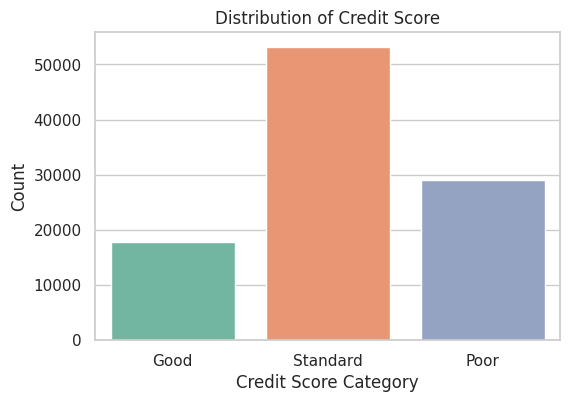

In [ ]:
# ======================================================
# 1. Distribution of Credit Score
# ======================================================
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_Score', data=data, palette='Set2')
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score Category")
plt.ylabel("Count")
plt.show()

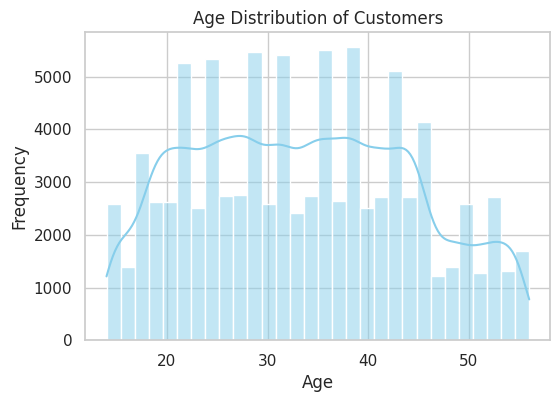

In [ ]:
# ======================================================
# 2. Age Distribution
# ======================================================
plt.figure(figsize=(6,4))
sns.histplot(data['Age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

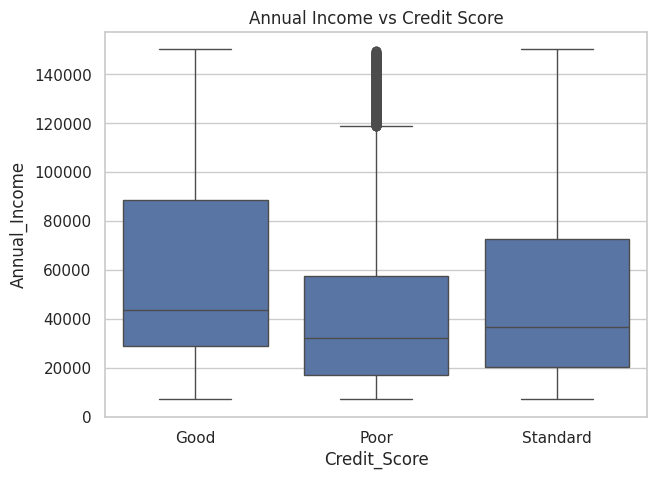

In [ ]:
# ======================================================
# 3. Income vs Credit Score
# ======================================================
plt.figure(figsize=(7,5))
sns.boxplot(x='Credit_Score', y='Annual_Income', data=data)
plt.title("Annual Income vs Credit Score")
plt.show()

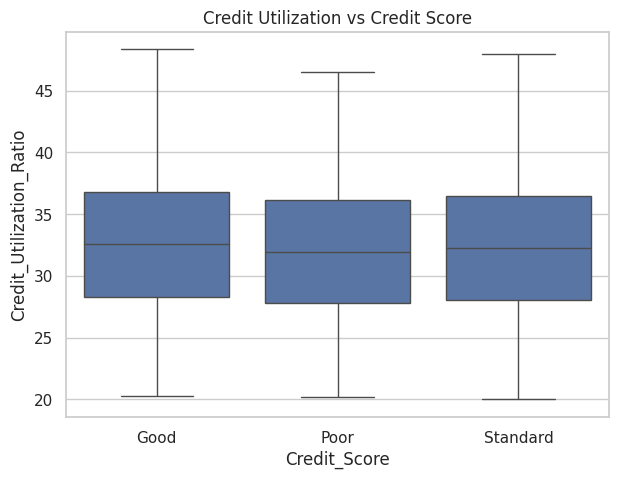

In [ ]:
# ======================================================
# 4. Credit Utilization vs Credit Score
# ======================================================
plt.figure(figsize=(7,5))
sns.boxplot(x='Credit_Score', y='Credit_Utilization_Ratio', data=data)
plt.title("Credit Utilization vs Credit Score")
plt.show()

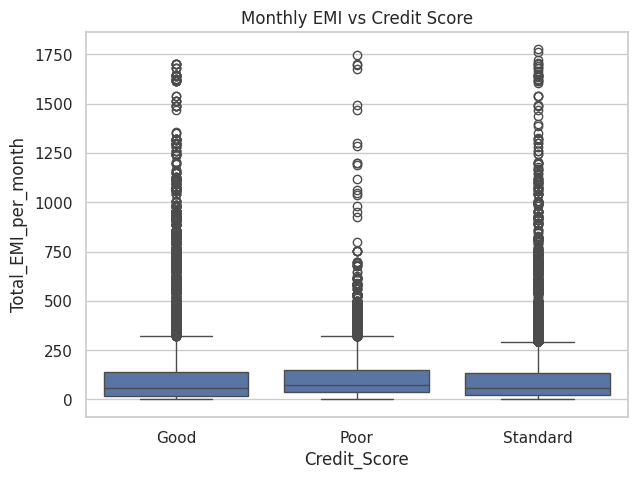

In [ ]:
# ======================================================
# 5. Monthly EMI vs Credit Score
# ======================================================
plt.figure(figsize=(7,5))
sns.boxplot(x='Credit_Score', y='Total_EMI_per_month', data=data)
plt.title("Monthly EMI vs Credit Score")
plt.show()

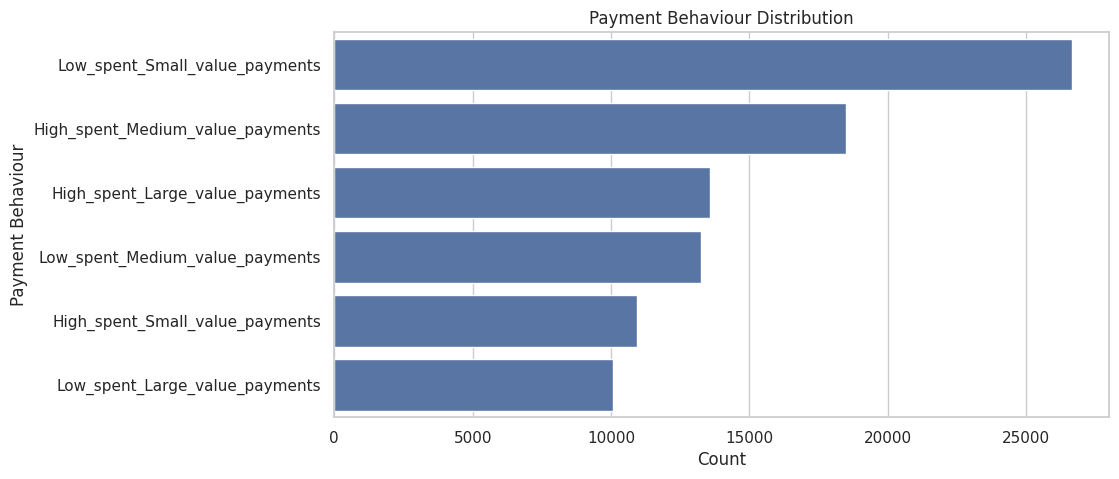

In [ ]:
# ======================================================
# 6. Payment Behaviour Analysis
# ======================================================
plt.figure(figsize=(10,5))
sns.countplot(y='Payment_Behaviour', data=data, order=data['Payment_Behaviour'].value_counts().index)
plt.title("Payment Behaviour Distribution")
plt.xlabel("Count")
plt.ylabel("Payment Behaviour")
plt.show()


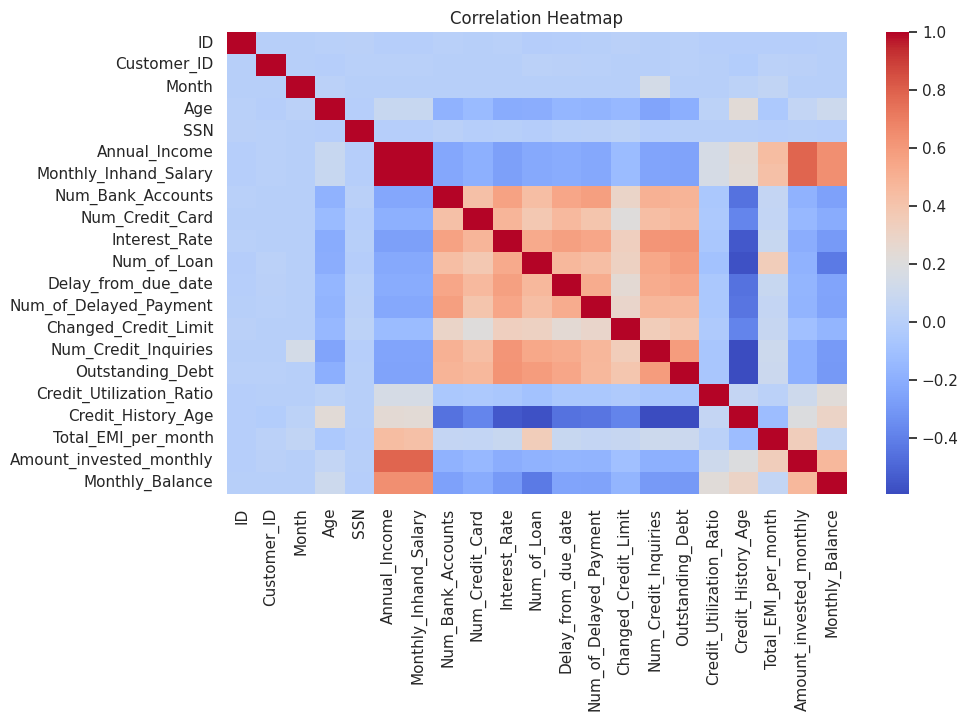

In [ ]:


# ======================================================
# 7. Correlation Heatmap
# ======================================================
plt.figure(figsize=(10,6))
numeric_df = data.select_dtypes(include=['float64','int64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# **Insights & Trends**

1. Credit Score Impact
Customers with lower credit scores show a significantly higher risk of default, while higher scores indicate better repayment behavior.

2. Income and Repayment Behavior
Higher-income customers generally manage EMIs more efficiently, whereas low-income groups exhibit greater repayment stress.

3. Credit Utilization Effect
High credit utilization ratios strongly correlate with increased default risk, making it a key indicator of financial instability.

4. Loan Amount and Tenure Influence
Larger loan amounts and longer repayment tenures increase the probability of delayed or missed payments.

5. Customer Risk Segmentation
Certain customer segments consistently show higher risk due to poor repayment history, high debt, or unstable income sources.

6. Business Insight
Identifying these patterns helps financial institutions improve credit scoring, reduce defaults, and design smarter lending strategies.

# **Recommendations**



1. **Strengthen Credit Scoring Models**
   Incorporate additional risk indicators such as credit utilization ratio, repayment history, and income stability to improve credit scoring accuracy.

2. **Segment Customers by Risk Level**
   Classify customers into low, medium, and high-risk groups to apply differentiated lending strategies and reduce default rates.

3. **Optimize Loan Amounts and Tenure**
   Limit high loan amounts for customers with lower income or unstable credit behavior to reduce repayment risk.

4. **Enhance Monitoring for High-Risk Profiles**
   Implement early-warning systems for customers showing rising debt levels or delayed payments to prevent future defaults.

5. **Promote Responsible Lending Practices**
   Encourage balanced loan offerings based on income-to-EMI ratios to maintain financial stability for borrowers.

6. **Improve Data Quality and Regular Monitoring**
   Continuously update customer data and monitor trends to ensure accurate risk assessment and timely decision-making.

7. **Use Insights for Policy Optimization**
   Leverage analytical findings to refine approval policies, interest rate structures, and risk mitigation strategies.



# **Conclusion**



The analysis shows that credit risk is strongly influenced by income level, credit utilization, and repayment behavior. Customers with stable income and lower debt are more reliable, while higher loan amounts and poor credit patterns increase default risk. These insights help PaisaBazaar improve credit decisions, reduce risk, and offer smarter lending solutions.
